## Ejercicio 3: Inspección visual de un producto

**Curso:** Inteligencia Artificial I (IS-484) · **Alumno:** Henry Josue Flores Saras

### Ficha PEAS

| Componente | Descripción |
|---|---|
| **Percepción (S)** | Imagen de 5×5 píxeles capturada por la cámara, como matriz de NumPy (0 = píxel normal, 1 = píxel defectuoso). |
| **Acciones (A)** | `aprobar` (el producto continúa en la línea), `revision manual` (se desvía a un operario), `rechazar` (se retira de la línea). |
| **Entorno (E)** | Línea de producción con banda transportadora, cámara de inspección, iluminación, operarios de control de calidad y productos que llegan de forma continua. |
| **Objetivo** | Que solo lleguen al cliente productos sin defectos, desperdiciando la menor cantidad posible de productos buenos. |
| **Medida de desempeño (P)** | % de productos defectuosos detectados (sensibilidad), % de productos buenos rechazados por error (falsos positivos), volumen enviado a revisión manual y productos inspeccionados por minuto. |

### Justificación de las reglas

Con 0 píxeles defectuosos no hay evidencia de falla y el producto se aprueba. De 1 a 3 defectos (hasta el 12 % de la imagen) el daño puede ser real o ruido del sensor (polvo, reflejo), así que conviene que un operario decida en vez de desechar un producto posiblemente bueno. Con más de 3 defectos el daño es evidente y revisarlo manualmente solo gastaría tiempo, por lo que se rechaza. Además, si la imagen no es 5×5 binaria se envía a revisión manual, porque una lectura corrupta de la cámara no debe aprobar ni rechazar nada.

### Código

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    imagen = np.asarray(imagen)
    # Validacion de la percepcion (lectura corrupta de la camara)
    if imagen.shape != (5, 5) or not np.isin(imagen, [0, 1]).all():
        return "revision manual", f"imagen no valida (forma {imagen.shape} o valores distintos de 0/1)"

    defectos = int(np.sum(imagen == 1))   # contar cuantos valores de la matriz son 1

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixel(es) defectuoso(s), posible defecto menor o ruido"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"

### Simulación y pruebas

Ejemplo del enunciado (3 defectos, BORDE superior de revision) -> ('revision manual', 'se detectaron 3 pixel(es) defectuoso(s), posible defecto menor o ruido')
Sin defectos                                                   -> ('aprobar', 'no se detectaron pixeles defectuosos')
1 defecto                                                      -> ('revision manual', 'se detectaron 1 pixel(es) defectuoso(s), posible defecto menor o ruido')
4 defectos (BORDE inferior de rechazo)                         -> ('rechazar', 'se detectaron 4 pixeles defectuosos')
8 defectos                                                     -> ('rechazar', 'se detectaron 8 pixeles defectuosos')
Lectura corrupta                                               -> ('revision manual', 'imagen no valida (forma (3, 3) o valores distintos de 0/1)')


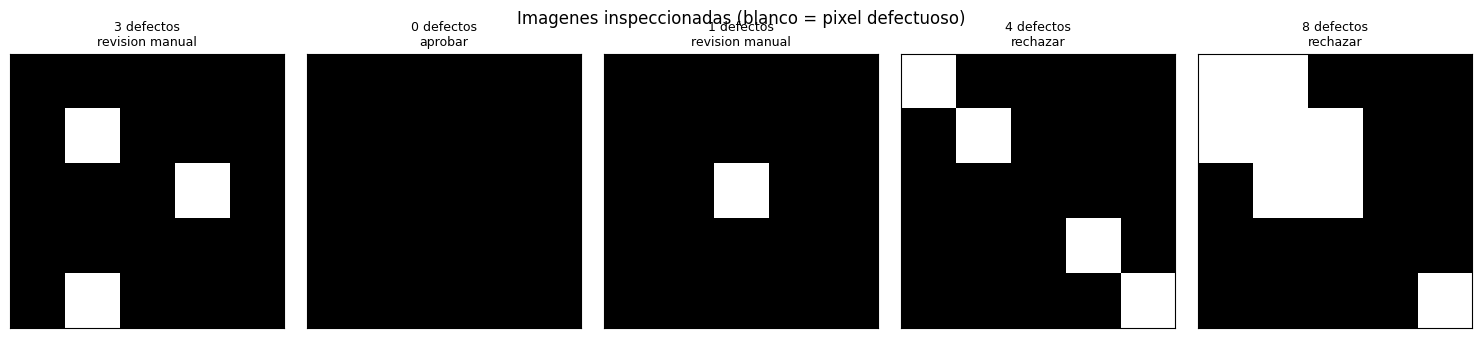

In [2]:
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])

imagen_sin_defectos = np.zeros((5, 5), dtype=int)

imagen_un_defecto = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

imagen_borde_4 = np.array([      # BORDE: 4 defectos, primer valor que se rechaza
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
])

imagen_muy_defectuosa = np.array([
    [1, 1, 0, 0, 0],
    [1, 1, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
])

imagen_corrupta = np.array([[0, 2, 0], [0, 0, 0], [1, 0, 0]])   # forma y valores invalidos

pruebas = [
    ("Ejemplo del enunciado (3 defectos, BORDE superior de revision)", imagen_prueba),
    ("Sin defectos", imagen_sin_defectos),
    ("1 defecto", imagen_un_defecto),
    ("4 defectos (BORDE inferior de rechazo)", imagen_borde_4),
    ("8 defectos", imagen_muy_defectuosa),
    ("Lectura corrupta", imagen_corrupta),
]

for nombre, img in pruebas:
    print(f"{nombre:<62} -> {agente_inspeccion(img)}")

# Visualizacion opcional de las imagenes validas
validas = [(n, i) for n, i in pruebas if i.shape == (5, 5)]
fig, axes = plt.subplots(1, len(validas), figsize=(3 * len(validas), 3.4))
for ax, (nombre, img) in zip(axes, validas):
    accion, _ = agente_inspeccion(img)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)   # blanco = defectuoso
    ax.set_title(f"{int(img.sum())} defectos\n{accion}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Imagenes inspeccionadas (blanco = pixel defectuoso)")
plt.tight_layout()
plt.show()
